In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.layers import Dense, Activation, Dropout

**Explicação:**
- Aqui são importadas as bibliotecas necessárias para a execução do modelo.
  - **NumPy** e **Pandas** são essenciais para manipulação de dados.
  - **Matplotlib** para visualizações.
  - **Keras** (parte do TensorFlow) é usado para construir o modelo LSTM.
  - **MinMaxScaler** da **Scikit-Learn** para normalizar os dados.
  - **math** e **mean_squared_error** são usados para calcular erros de previsão.

In [ ]:
input_file="DIS.csv"

In [ ]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	return np.array(dataX), np.array(dataY)

**Explicação:**
- Essa função cria um conjunto de dados para alimentar a rede LSTM. Ela utiliza uma janela deslizante (`look_back`) para criar sequências de dados (`dataX`) e os respectivos valores futuros (`dataY`).
- A função basicamente divide a série temporal em sequências para treinar o modelo.

In [ ]:
# fix random seed for reproducibility
np.random.seed(5)

In [ ]:
# load the dataset
df = read_csv(input_file, header=None, index_col=None, delimiter=',')

In [ ]:
df.shape

(5035, 7)

In [ ]:
df.head()

,0,1,2,3,4,5,6
0,1996-12-31,23.011177,23.175543,22.805719,22.928993,17.804647,2719200
1,1997-01-02,22.928993,22.970085,21.942801,22.148258,17.198397,8115400
2,1997-01-03,22.394806,22.805719,22.394806,22.764629,17.677013,4650000
3,1997-01-06,22.764629,22.928993,22.559172,22.682446,17.613201,3623300
4,1997-01-07,22.682446,22.682446,22.435898,22.641354,17.581289,3606200


**Explicação:**
- O dataset é carregado do arquivo `DIS.csv`. O parâmetro `header=None` indica que o arquivo não contém cabeçalhos, e `index_col=None` especifica que não há uma coluna de índice no arquivo CSV.

In [ ]:
# take close price column[5]
all_y = df[5].values
dataset=all_y.reshape(-1, 1)

**Explicação:**
- Este bloco seleciona a coluna de preços de fechamento de ações, que está na posição 5 do CSV. Em seguida, os valores são transformados em um array 2D para normalização posterior.

In [ ]:
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

**Explicação:**
- A normalização é essencial para que a rede neural aprenda mais rapidamente, já que LSTM pode ser sensível a escalas de dados.
- O `MinMaxScaler` transforma os valores para o intervalo entre 0 e 1.

In [ ]:
# split into train and test sets, 50% test data, 50% training data
train_size = int(len(dataset) * 0.5)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

**Explicação:**
- A divisão do dataset em treino e teste ocorre aqui, com 50% dos dados usados para cada um.
- **Sugestão:** A divisão de 50% para treino/teste é arbitrária. Dependendo do tamanho dos dados, uma divisão mais comum seria 80% para treino e 20% para teste, o que pode melhorar a generalização do modelo.

In [ ]:
# reshape into X=t and Y=t+1, timestep 240
look_back = 240
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

**Explicação:**
- Utiliza-se a função `create_dataset()` para gerar as sequências de entrada e saída com uma janela de 240 timesteps (`look_back=240`).
- **Sugestão:** Se a série temporal for muito longa, 240 timesteps pode ser muito grande, o que pode prejudicar o desempenho. Testar diferentes valores de `look_back` pode ser útil.

In [ ]:
# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

- Para alimentar o modelo LSTM, os dados precisam ser tridimensionais: `[amostras, time steps, características]`. Aqui, o código ajusta as dimensões para que o modelo aceite os dados.

In [ ]:
# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
model.add(LSTM(25, input_shape=(look_back, 1)))
model.add(Dropout(0.1))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
model.fit(trainX, trainY, epochs=10, batch_size=240, verbose=1) # alterar epoca para valor maior....

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0093
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0015
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0014
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0012
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 8.2787e-04
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 6.8648e-04
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 5.4664e-04
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 3.8889e-04
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 2.6881e-04
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 2.2429e-04


**Explicação:**
- Um modelo sequencial é criado com um LSTM de 25 unidades. Após a camada LSTM, há uma camada `Dropout` para evitar overfitting.
- O modelo é compilado com a função de perda **MSE** e o otimizador **Adam**.
- **Sugestão:** Considerar o aumento do número de épocas (como mencionado) e a possibilidade de adicionar mais camadas LSTM, dependendo da complexidade do problema. A quantidade de unidades LSTM também pode ser ajustada conforme os resultados.

In [ ]:
# make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


**Explicação:**
- O modelo realiza previsões para os dados de treino e teste.

In [ ]:
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

**Explicação:**
- As previsões precisam ser invertidas de volta para o intervalo original (antes da normalização). O método `inverse_transform` é utilizado.

In [ ]:
# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 1.21 RMSE
Test Score: 13.37 RMSE


**Explicação:**
- A métrica de erro RMSE é calculada para avaliar o desempenho do modelo.

In [ ]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

In [ ]:
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

**Explicação:**
- Esses blocos são responsáveis por organizar as previsões para que possam ser plotadas junto com os dados reais.

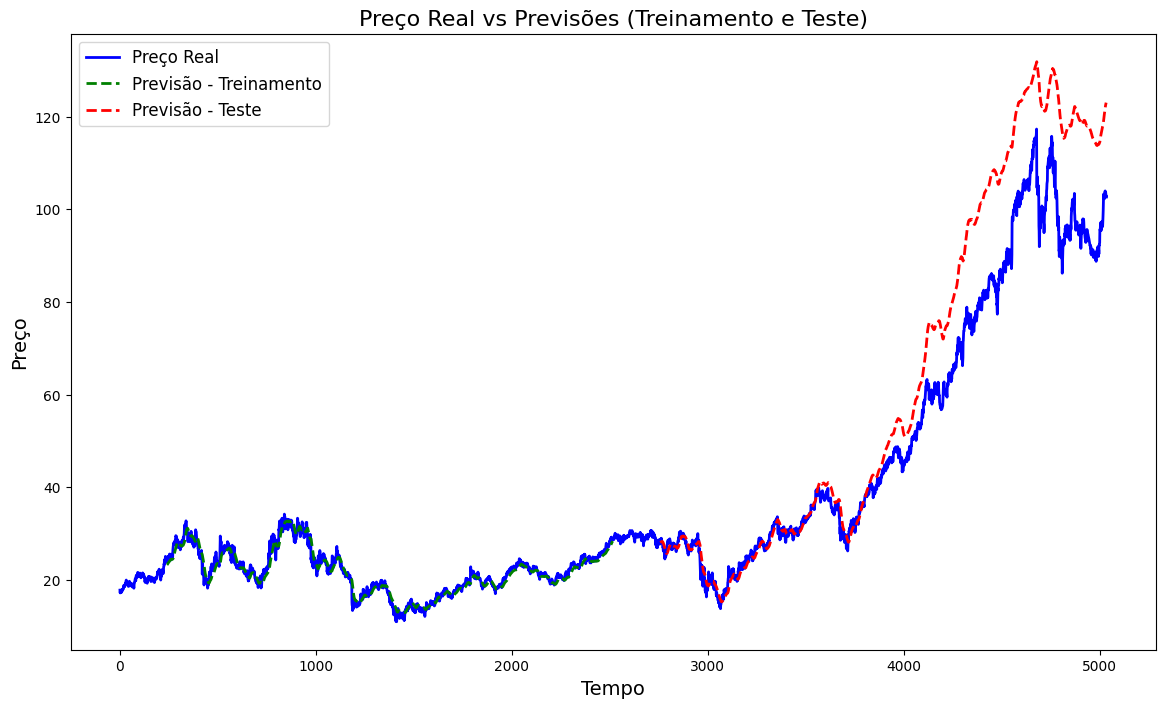

testPrices:
testPredictions:
[[ 28.09633 ]
 [ 28.128626]
 [ 28.162903]
 ...
 [122.63374 ]
 [122.85834 ]
 [123.00105 ]]


In [ ]:
# plot baseline and predictions
plt.figure(figsize=(14, 8))  # Define the figure size
plt.plot(scaler.inverse_transform(dataset), label='Preço Real', color='blue', linewidth=2)
plt.plot(trainPredictPlot, label='Previsão - Treinamento', color='green', linestyle='dashed', linewidth=2)
plt.plot(testPredictPlot, label='Previsão - Teste', color='red', linestyle='dashed', linewidth=2)

# Adiciona título e legendas
plt.title('Preço Real vs Previsões (Treinamento e Teste)', fontsize=16)
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Preço', fontsize=14)
plt.legend(loc='best', fontsize=12)

# Exibe o gráfico
plt.show()

# Imprime os valores para análise
print('testPrices:')
testPrices = scaler.inverse_transform(dataset[test_size + look_back:])
print('testPredictions:')
print(testPredict)


**Explicação:**
- O gráfico é gerado com os dados reais e as previsões do modelo.

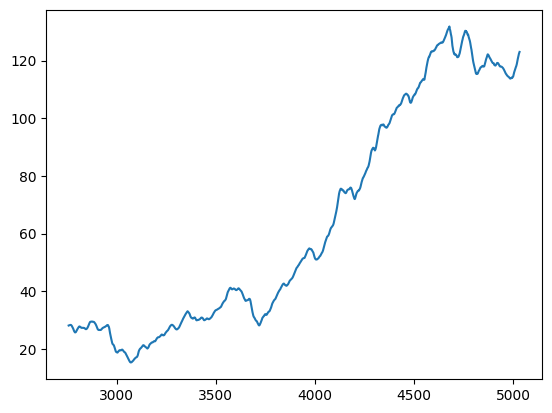

In [ ]:
# plot the actual price, prediction in test data=red line, actual price=blue line
plt.plot(testPredictPlot)
plt.show()

**Explicação:**
- O gráfico final mostra as previsões do teste em comparação com os valores reais.